<a href="https://colab.research.google.com/github/srujith2006/ObjectDetection/blob/main/C_Obj_Classi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
cnn_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
features=[]
labels=[]

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving disaster detection.v1-flood1.folder.zip to disaster detection.v1-flood1.folder (1).zip


In [ ]:
data = "/content/disaster detection.v1-flood1.folder.zip"

In [ ]:
print(data)
print(type(features))
print(type(labels))

/content/disaster detection.v1-flood1.folder.zip
<class 'list'>
<class 'list'>


In [ ]:
print(set(labels))

set()


In [ ]:
import zipfile

# Original data variable points to the zip file. We need to extract it first.
zip_file_path = data # Use the existing 'data' variable value which points to the zip file
extracted_dir = '/content/extracted_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extracted_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)

# Update 'data' to point to the extracted directory
data = os.path.join(extracted_dir, "train")

for label in os.listdir(data):
  class_path=os.path.join(data,label)
  # Added checks for directory and file existence, as some files like READMEs might be present
  if not os.path.isdir(class_path):
      print(f"Warning: Skipping {class_path} as it is not a directory.")
      continue

  for image_name in os.listdir(class_path):
    image_path=os.path.join(class_path,image_name)

    if not os.path.isfile(image_path):
        print(f"Warning: Skipping {image_path} as it is not a file.")
        continue

    image=cv2.imread(image_path)
    if image is None: # Corrected from 'img is None' to 'image is None'
      print(f"Warning: Could not read image at {image_path}. Skipping.")
      continue
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image=cv2.resize(image,(224,224))
    img=preprocess_input(image)
    img=np.expand_dims(img,axis=0)
    feature=cnn_model.predict(img)
    features.append(feature.flatten())
    labels.append(label)
print("Image processing and feature extraction complete.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━

In [ ]:
X = np.array(features)
y = np.array(labels)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
svm_model = SVC(random_state=42) # Instantiate the Support Vector Classifier
svm_model.fit(X_train, y_train) # Train the model with the training data
y_pred = svm_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9886621315192744


array([[[ 2, 16, 38],
        [ 2, 16, 38],
        [ 2, 16, 38],
        ...,
        [ 0, 10, 39],
        [ 5, 21, 58],
        [14, 31, 70]],

       [[ 2, 16, 38],
        [ 2, 16, 38],
        [ 2, 16, 38],
        ...,
        [ 0, 15, 48],
        [12, 29, 68],
        [22, 40, 81]],

       [[ 2, 16, 38],
        [ 2, 16, 38],
        [ 2, 16, 38],
        ...,
        [ 5, 26, 64],
        [18, 39, 84],
        [24, 47, 93]],

       ...,

       [[ 2, 16, 68],
        [ 4, 19, 68],
        [ 5, 20, 66],
        ...,
        [ 3,  3,  9],
        [ 3,  3,  9],
        [ 3,  3,  9]],

       [[ 0,  9, 58],
        [ 0, 11, 59],
        [ 5, 18, 62],
        ...,
        [ 3,  3,  9],
        [ 3,  3,  9],
        [ 3,  3,  9]],

       [[ 0,  5, 53],
        [ 0,  6, 52],
        [ 5, 16, 60],
        ...,
        [ 3,  3,  9],
        [ 3,  3,  9],
        [ 3,  3,  9]]], dtype=uint8)
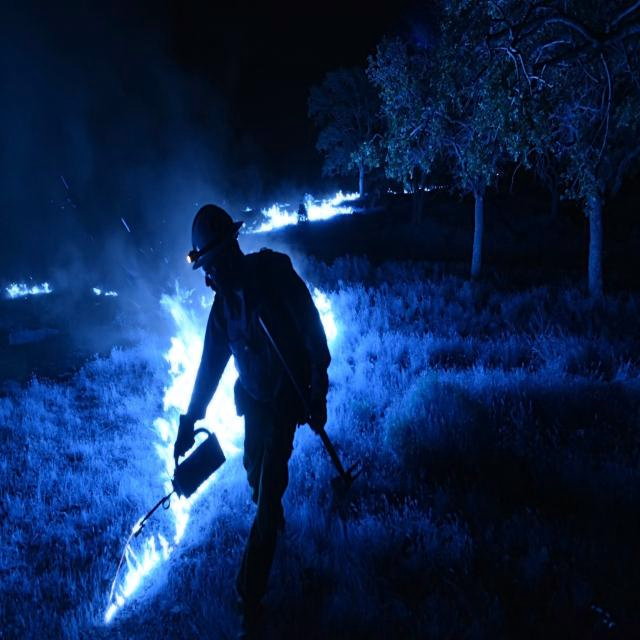

In [25]:
test_img = cv2.imread("/content/fire-105_png.rf.91f8ee9914800289443a13962362b5e8.jpg")
test_img

In [26]:
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_img = cv2.resize(test_img, (224,224))

test_img = preprocess_input(test_img)

test_img = np.expand_dims(test_img, axis=0)

feature = cnn_model.predict(test_img)

feature = feature.flatten().reshape(1, -1)

# Check for and handle NaN/inf values in the feature vector
if np.isnan(feature).any() or np.isinf(feature).any():
    print("Warning: Feature vector contains NaN or infinite values. Replacing with 0.")
    feature = np.nan_to_num(feature, nan=0.0, posinf=0.0, neginf=0.0)

prediction = svm_model.predict(feature)

print("Predicted Class:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Class: fire_images
